# US Flight Delays Network Analysis
## Step 3: Graph Analytics & Delay Propagation

**Course:** CS-GY 6513-C Big Data — Spring 2026

**Team:** Mirsaid Abbasov [ma9197], Nicholas Pesa [np2354], Ferdi Fadillah [ff2364]

---

In this step we compute graph-theoretic metrics on the airport-route network built in Step 2 to identify **delay-critical airports** and **fragile routes** (Objectives 2 & 3 from the proposal).

### Metrics Computed
- **Degree centrality** — how connected an airport is (Spark)
- **Weighted PageRank** — influence weighted by flight traffic
- **Delay-weighted PageRank** — influence weighted by delay severity
- **Betweenness centrality** — how often an airport sits on shortest paths (bridge importance)
- **Delay propagation score** — combined metric: centrality × delay rate
- **Fragile routes** — edges ranked by (traffic × delay rate)

### Tooling note
Per the proposal, graph analytics uses GraphFrames where available, with custom computations as fallback. Because Spark 4.0 on Colab has compatibility issues with GraphFrames, we use **NetworkX** for centrality algorithms that benefit from optimized shortest-path routines (betweenness especially). Spark is still used for loading, degree stats, and final enrichment. The graph is 381 nodes / ~8K edges — small enough that NetworkX is actually faster than distributed computation, but the *aggregation that produced it* was done with Spark on 30M+ flight records.

### Outputs
- `nodes_enriched_centrality.parquet` — nodes with all centrality metrics
- `edges_with_risk.parquet` — edges with fragility scores
- Ranked airport and route tables
- Network map visualization

## 1. Environment Setup

In [1]:
!pip install pyspark networkx -q

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

spark = SparkSession.builder \
    .appName("FlightDelays_Step3") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print(f"Spark version:    {spark.version}")
print(f"NetworkX version: {nx.__version__}")

Spark version:    4.0.2
NetworkX version: 3.6.1


## 2. Load Graph from Step 2

In [4]:
NODES_PATH = "/content/drive/MyDrive/Big Data Project/parquet/graph_nodes"
EDGES_PATH = "/content/drive/MyDrive/Big Data Project/parquet/graph_edges"

nodes_sdf = spark.read.parquet(NODES_PATH)
edges_sdf = spark.read.parquet(EDGES_PATH)

print(f"Nodes: {nodes_sdf.count()}")
print(f"Edges: {edges_sdf.count()}")

Nodes: 381
Edges: 8128


## 3. Convert to NetworkX Graph

Since the graph is small (381 nodes), we convert the Spark edges into a NetworkX DiGraph for centrality calculations. The underlying aggregations that built these edges — scanning 30M+ flight records — were done in Spark in Step 2.

In [5]:
# Bring edges into pandas (small enough)
edges_pdf = edges_sdf.toPandas()
nodes_pdf = nodes_sdf.toPandas()

print(f"Edges pandas shape: {edges_pdf.shape}")
print(f"Nodes pandas shape: {nodes_pdf.shape}")
edges_pdf.head()

Edges pandas shape: (8128, 7)
Nodes pandas shape: (381, 13)


,src,dst,num_flights,avg_dep_delay,avg_arr_delay,pct_delayed_15,avg_distance
0,CMH,MSP,5786,6.791047,-0.639302,0.123920,626.0
1,DTW,LEX,4733,5.689837,-0.487851,0.122966,296.0
2,LGA,MEM,4803,9.345409,0.789298,0.204039,963.0
3,MSP,CVG,7320,4.226230,-2.500956,0.132240,596.0
4,BOS,PHX,7218,11.092269,-2.284012,0.179690,2300.0


In [6]:
# Build a directed graph; attach edge attributes
G = nx.DiGraph()

for _, row in edges_pdf.iterrows():
    G.add_edge(
        row['src'],
        row['dst'],
        num_flights=float(row['num_flights']),
        avg_dep_delay=float(row['avg_dep_delay']),
        avg_arr_delay=float(row['avg_arr_delay']),
        pct_delayed=float(row['pct_delayed_15']),
        distance=float(row['avg_distance'])
    )

print(f"Graph nodes: {G.number_of_nodes()}")
print(f"Graph edges: {G.number_of_edges()}")
print(f"Density:     {nx.density(G):.4f}")

Graph nodes: 381
Graph edges: 8128
Density:     0.0561


## 4. Centrality Measures

### 4.1 Degree Centrality
Basic measure — how many unique connections does an airport have.

### 4.2 Weighted PageRank (Traffic-Weighted)
Classic PageRank but edges weighted by flight volume. Answers: *"Which airports are central hubs in the passenger flow network?"*

### 4.3 Delay-Weighted PageRank
Edges weighted by `num_flights × pct_delayed`. Answers: *"Which airports are central in the **delay** flow — where most delay-minutes actually move through?"*

### 4.4 Betweenness Centrality
How often an airport lies on shortest paths between other airports. High betweenness = bridge airport; its failure cuts the network in two.

In [7]:
# Degree centrality
in_deg  = nx.in_degree_centrality(G)
out_deg = nx.out_degree_centrality(G)

# PageRank weighted by traffic
pr_traffic = nx.pagerank(G, weight='num_flights', alpha=0.85)

# For delay-weighted PageRank, compute a combined weight per edge
for u, v, data in G.edges(data=True):
    # weighted by number of delayed flights (approx = num_flights * pct_delayed)
    data['delay_weight'] = data['num_flights'] * max(data['pct_delayed'], 0.0)

pr_delay = nx.pagerank(G, weight='delay_weight', alpha=0.85)

print("PageRank (traffic-weighted) computed for", len(pr_traffic), "airports")
print("PageRank (delay-weighted)   computed for", len(pr_delay), "airports")

PageRank (traffic-weighted) computed for 381 airports
PageRank (delay-weighted)   computed for 381 airports


In [8]:
# Betweenness centrality — can be slow on 381 nodes but manageable
# Using weight=1/num_flights so "shorter" means higher-traffic
for u, v, data in G.edges(data=True):
    data['inv_flights'] = 1.0 / max(data['num_flights'], 1.0)

print("Computing betweenness... (may take 1-2 min)")
betweenness = nx.betweenness_centrality(G, weight='inv_flights', normalized=True)
print("Done.")

Computing betweenness... (may take 1-2 min)
Done.


## 5. Combine Centrality with Delay Stats

We bring centrality metrics back into the Spark-enriched nodes table and compute the final **delay propagation score**:

$$
\text{propagation\_score} = \text{pagerank\_delay} \times \text{out\_pct\_delayed\_15}
$$

This flags airports that are **both central in the delay network AND have high local delay rates** — the true disruption engines.

In [9]:
# Build a centrality DataFrame
cent_pdf = pd.DataFrame({
    'iata': list(G.nodes()),
    'in_degree_centrality':  [in_deg[n]      for n in G.nodes()],
    'out_degree_centrality': [out_deg[n]     for n in G.nodes()],
    'pagerank_traffic':      [pr_traffic[n]  for n in G.nodes()],
    'pagerank_delay':        [pr_delay[n]    for n in G.nodes()],
    'betweenness':           [betweenness[n] for n in G.nodes()],
})

print(cent_pdf.shape)
cent_pdf.head()

(381, 6)


,iata,in_degree_centrality,out_degree_centrality,pagerank_traffic,pagerank_delay,betweenness
0,CMH,0.128947,0.128947,0.004689,0.004507,0.000000
1,MSP,0.376316,0.376316,0.020654,0.016309,0.105020
2,DTW,0.331579,0.331579,0.019571,0.015725,0.067220
3,LEX,0.057895,0.057895,0.001390,0.001252,0.000000
4,LGA,0.260526,0.260526,0.016233,0.018539,0.011651


In [10]:
# Merge centrality back into Spark nodes table
cent_sdf = spark.createDataFrame(cent_pdf)
nodes_full = nodes_sdf.join(cent_sdf, on='iata', how='left')

# Compute delay propagation score
nodes_full = nodes_full.withColumn(
    'delay_propagation_score',
    F.col('pagerank_delay') * F.col('out_pct_delayed_15')
)

print(f"Final nodes table: {nodes_full.count()} rows, {len(nodes_full.columns)} cols")
nodes_full.columns

Final nodes table: 381 rows, 19 cols


['iata',
 'out_degree',
 'total_out_flights',
 'avg_out_dep_delay',
 'out_pct_delayed_15',
 'in_degree',
 'total_in_flights',
 'avg_in_arr_delay',
 'in_pct_delayed_15',
 'name',
 'city',
 'latitude',
 'longitude',
 'in_degree_centrality',
 'out_degree_centrality',
 'pagerank_traffic',
 'pagerank_delay',
 'betweenness',
 'delay_propagation_score']

## 6. Results — Delay-Critical Airports

In [11]:
# Top 15 by traffic PageRank
print("=== TOP 15 BY TRAFFIC-WEIGHTED PAGERANK (biggest hubs) ===")
nodes_full.orderBy(F.desc('pagerank_traffic')).select(
    'iata', 'name', 'city', 'pagerank_traffic', 'total_out_flights'
).show(15, truncate=False)

=== TOP 15 BY TRAFFIC-WEIGHTED PAGERANK (biggest hubs) ===
+----+----------------------------------------------------------+-----------------+--------------------+-----------------+
|iata|name                                                      |city             |pagerank_traffic    |total_out_flights|
+----+----------------------------------------------------------+-----------------+--------------------+-----------------+
|ATL |Hartsfield Jackson Atlanta International Airport          |Atlanta          |0.044854079489878844|1590429          |
|DFW |Dallas Fort Worth International Airport                   |Dallas-Fort Worth|0.04390824703060186 |1327965          |
|DEN |Denver International Airport                              |Denver           |0.04150328871217308 |1236560          |
|ORD |Chicago O'Hare International Airport                      |Chicago          |0.040032407731601084|1249272          |
|CLT |Charlotte Douglas International Airport                   |Charlotte      

In [12]:
# Top 15 by delay-weighted PageRank
print("=== TOP 15 BY DELAY-WEIGHTED PAGERANK (central in delay flow) ===")
nodes_full.orderBy(F.desc('pagerank_delay')).select(
    'iata', 'name', 'city', 'pagerank_delay', 'avg_out_dep_delay', 'out_pct_delayed_15'
).show(15, truncate=False)

=== TOP 15 BY DELAY-WEIGHTED PAGERANK (central in delay flow) ===
+----+----------------------------------------------------------+-----------------+--------------------+------------------+-------------------+
|iata|name                                                      |city             |pagerank_delay      |avg_out_dep_delay |out_pct_delayed_15 |
+----+----------------------------------------------------------+-----------------+--------------------+------------------+-------------------+
|DFW |Dallas Fort Worth International Airport                   |Dallas-Fort Worth|0.04757181550566582 |12.51740821482494 |0.21461936120304376|
|DEN |Denver International Airport                              |Denver           |0.04344048745657153 |13.10540531797891 |0.22224801061007957|
|ORD |Chicago O'Hare International Airport                      |Chicago          |0.04127305210553906 |11.117877451827944|0.2055268988658995 |
|ATL |Hartsfield Jackson Atlanta International Airport          |Atlan

In [13]:
# Top 15 by betweenness (bridge airports)
print("=== TOP 15 BY BETWEENNESS (bridge airports) ===")
nodes_full.orderBy(F.desc('betweenness')).select(
    'iata', 'name', 'city', 'betweenness', 'out_degree'
).show(15, truncate=False)

=== TOP 15 BY BETWEENNESS (bridge airports) ===
+----+----------------------------------------------------------+-----------------+--------------------+----------+
|iata|name                                                      |city             |betweenness         |out_degree|
+----+----------------------------------------------------------+-----------------+--------------------+----------+
|ATL |Hartsfield Jackson Atlanta International Airport          |Atlanta          |0.3321621996944869  |175       |
|DEN |Denver International Airport                              |Denver           |0.29393139841688654 |205       |
|ORD |Chicago O'Hare International Airport                      |Chicago          |0.24658380780447162 |199       |
|DFW |Dallas Fort Worth International Airport                   |Dallas-Fort Worth|0.20327037911401194 |201       |
|SEA |Seattle Tacoma International Airport                      |Seattle          |0.15588112762116374 |97        |
|LAX |Los Angeles Intern

In [14]:
# FINAL RANKING — Delay Propagation Score
print("=== TOP 20 MOST DELAY-PROPAGATING AIRPORTS ===")
print("(airports that are both central in the network AND have high local delays)\n")
nodes_full \
    .filter(F.col('total_out_flights') >= 10000) \
    .orderBy(F.desc('delay_propagation_score')) \
    .select(
        'iata', 'name', 'city',
        'delay_propagation_score', 'pagerank_delay',
        'out_pct_delayed_15', 'total_out_flights'
    ).show(20, truncate=False)

=== TOP 20 MOST DELAY-PROPAGATING AIRPORTS ===
(airports that are both central in the network AND have high local delays)

+----+----------------------------------------------------------+-----------------+-----------------------+--------------------+-------------------+-----------------+
|iata|name                                                      |city             |delay_propagation_score|pagerank_delay      |out_pct_delayed_15 |total_out_flights|
+----+----------------------------------------------------------+-----------------+-----------------------+--------------------+-------------------+-----------------+
|DFW |Dallas Fort Worth International Airport                   |Dallas-Fort Worth|0.01020983265509505    |0.04757181550566582 |0.21461936120304376|1327965          |
|DEN |Denver International Airport                              |Denver           |0.009654561917155137   |0.04344048745657153 |0.22224801061007957|1236560          |
|ORD |Chicago O'Hare International Airport

## 7. Results — Fragile Routes

A route is "fragile" when it combines high traffic with high delay rate — disruption here affects many flights. Score: `num_flights × pct_delayed_15`.

In [15]:
# Add fragility score to edges
edges_scored = edges_sdf.withColumn(
    'fragility_score',
    F.col('num_flights') * F.col('pct_delayed_15')
)

print("=== TOP 20 MOST FRAGILE ROUTES ===")
edges_scored \
    .filter(F.col('num_flights') >= 1000) \
    .orderBy(F.desc('fragility_score')) \
    .select('src', 'dst', 'num_flights', 'pct_delayed_15',
            'avg_dep_delay', 'fragility_score') \
    .show(20, truncate=False)

=== TOP 20 MOST FRAGILE ROUTES ===
+---+---+-----------+-------------------+------------------+-----------------+
|src|dst|num_flights|pct_delayed_15     |avg_dep_delay     |fragility_score  |
+---+---+-----------+-------------------+------------------+-----------------+
|ORD|LGA|46416      |0.23595311961392623|14.55149086521889 |10952.0          |
|LAX|SFO|54442      |0.18985342199037508|8.854487344329746 |10336.0          |
|LAS|LAX|47614      |0.20139034737682193|10.985949510648128|9589.0           |
|LGA|ORD|46511      |0.20261873535292727|13.666057491776138|9424.0           |
|LAX|LAS|47690      |0.19704340532606415|9.671146990983434 |9397.0           |
|SFO|LAX|54453      |0.16316823682809029|8.016619837290875 |8885.0           |
|MCO|EWR|30208      |0.2850900423728814 |19.84527277542373 |8612.0           |
|JFK|LAX|45460      |0.18919929608446986|9.969159700835899 |8601.0           |
|LAX|JFK|45426      |0.18597279091269317|12.985008585391626|8448.0           |
|DEN|LAS|35122   

## 8. Visualizations

In [16]:
# Pull top data to pandas for plotting
top_propagation = nodes_full \
    .filter(F.col('total_out_flights') >= 10000) \
    .orderBy(F.desc('delay_propagation_score')) \
    .limit(15) \
    .toPandas()

top_betweenness = nodes_full \
    .orderBy(F.desc('betweenness')) \
    .limit(15) \
    .toPandas()

top_fragile = edges_scored \
    .filter(F.col('num_flights') >= 1000) \
    .orderBy(F.desc('fragility_score')) \
    .limit(15) \
    .toPandas()

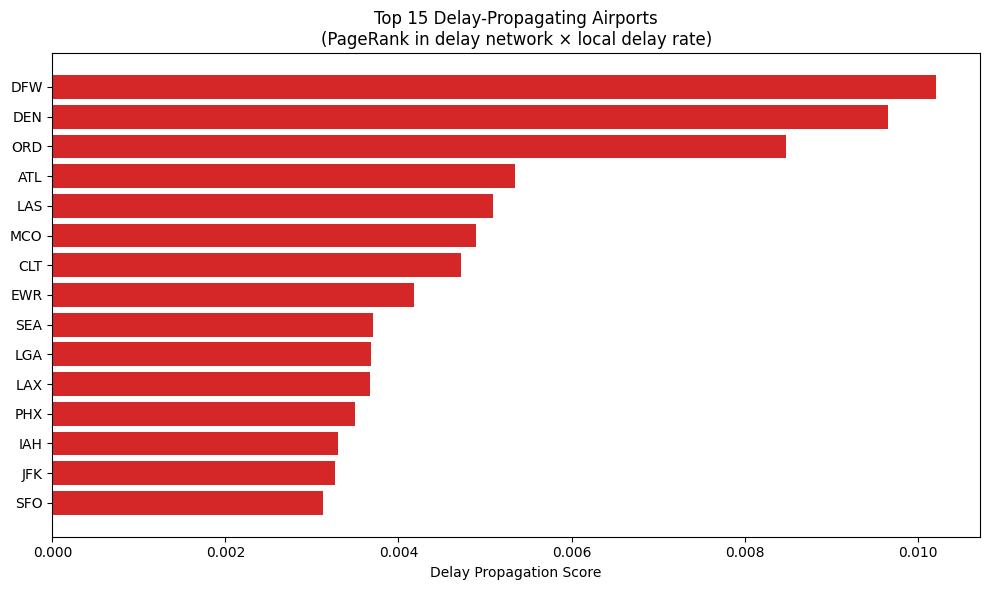

In [17]:
# Bar chart — top delay propagators
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_propagation['iata'][::-1], top_propagation['delay_propagation_score'][::-1], color='#d62728')
ax.set_xlabel('Delay Propagation Score')
ax.set_title('Top 15 Delay-Propagating Airports\n(PageRank in delay network × local delay rate)')
plt.tight_layout()
plt.show()

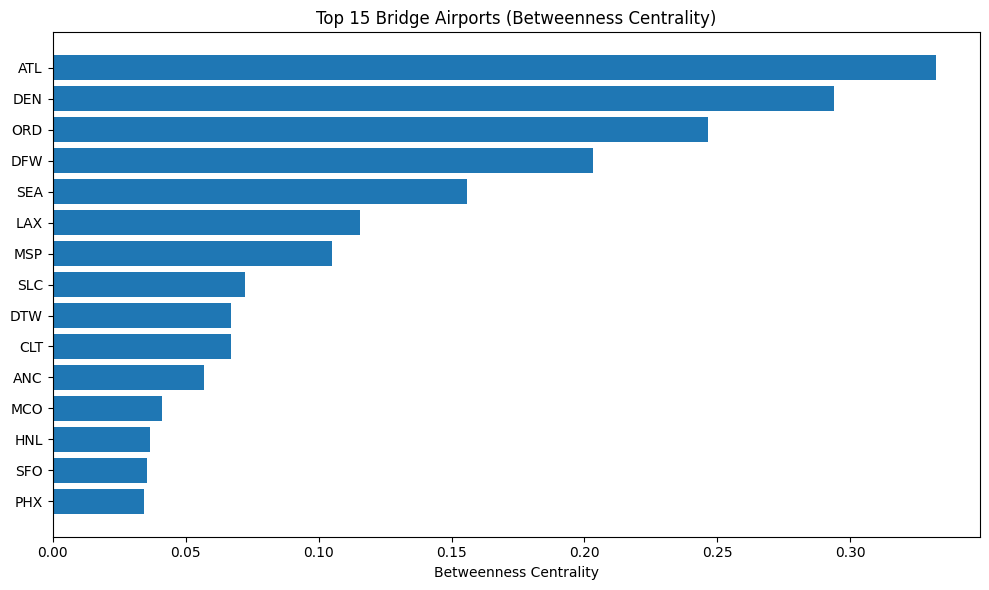

In [18]:
# Bar chart — top betweenness
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_betweenness['iata'][::-1], top_betweenness['betweenness'][::-1], color='#1f77b4')
ax.set_xlabel('Betweenness Centrality')
ax.set_title('Top 15 Bridge Airports (Betweenness Centrality)')
plt.tight_layout()
plt.show()

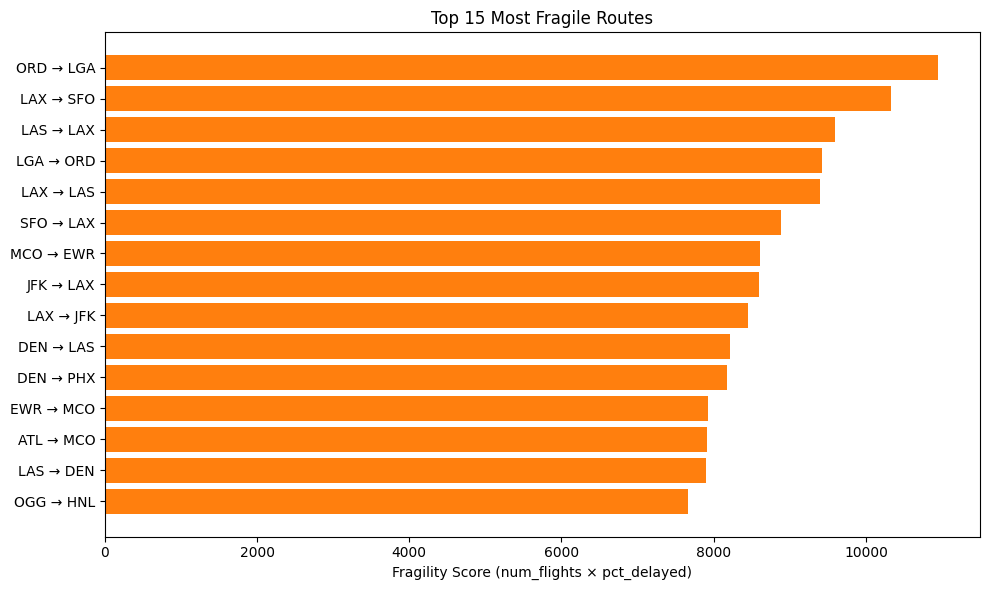

In [19]:
# Bar chart — top fragile routes
route_labels = top_fragile['src'] + ' \u2192 ' + top_fragile['dst']

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(route_labels[::-1], top_fragile['fragility_score'][::-1], color='#ff7f0e')
ax.set_xlabel('Fragility Score (num_flights × pct_delayed)')
ax.set_title('Top 15 Most Fragile Routes')
plt.tight_layout()
plt.show()

### Network Map Visualization
US map showing top 50 hubs (by traffic-weighted PageRank) and top 100 busiest routes.

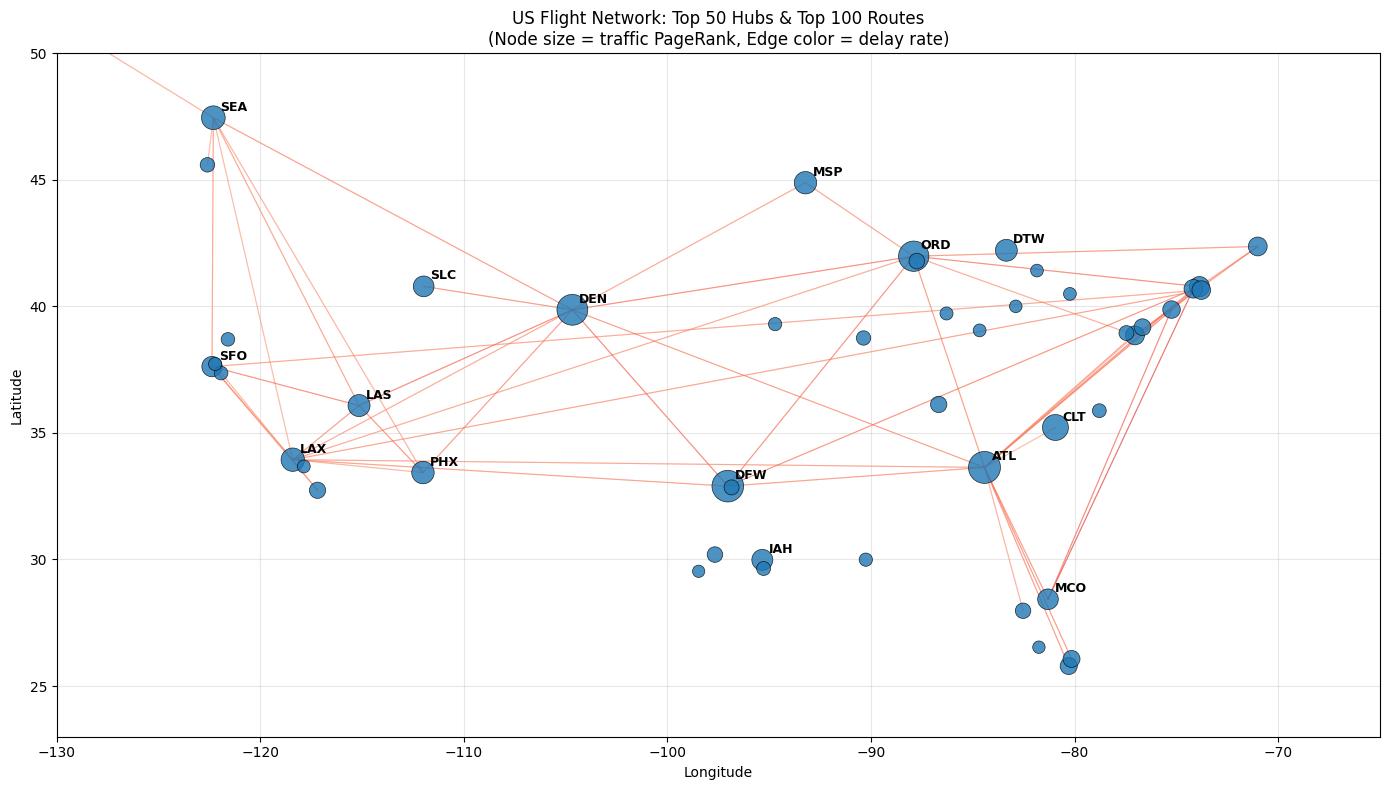

In [20]:
# Get nodes with valid coordinates
nodes_map = nodes_full.filter(
    F.col('latitude').isNotNull() & F.col('longitude').isNotNull()
).toPandas()

# Top 50 by traffic PageRank
top_hubs = nodes_map.nlargest(50, 'pagerank_traffic')
top_hub_iatas = set(top_hubs['iata'])

# Top 100 busiest routes where both endpoints are in top hubs
top_routes = edges_pdf.nlargest(200, 'num_flights')
top_routes = top_routes[
    top_routes['src'].isin(top_hub_iatas) &
    top_routes['dst'].isin(top_hub_iatas)
].head(100)

# Coord lookup
coord_lookup = nodes_map.set_index('iata')[['latitude', 'longitude']].to_dict('index')

fig, ax = plt.subplots(figsize=(14, 8))

# Draw routes (colored by delay rate)
for _, route in top_routes.iterrows():
    if route['src'] in coord_lookup and route['dst'] in coord_lookup:
        s = coord_lookup[route['src']]
        d = coord_lookup[route['dst']]
        delay_color = plt.cm.Reds(min(route['pct_delayed_15'] * 2.5, 1.0))
        ax.plot(
            [s['longitude'], d['longitude']],
            [s['latitude'],  d['latitude']],
            color=delay_color, alpha=0.4, linewidth=0.8, zorder=1
        )

# Draw airports
sizes = (top_hubs['pagerank_traffic'] / top_hubs['pagerank_traffic'].max() * 500) + 30
ax.scatter(
    top_hubs['longitude'], top_hubs['latitude'],
    s=sizes, c='#1f77b4', alpha=0.8, edgecolors='black', linewidth=0.5, zorder=2
)

# Label top 15
for _, hub in top_hubs.head(15).iterrows():
    ax.annotate(
        hub['iata'],
        (hub['longitude'], hub['latitude']),
        fontsize=9, fontweight='bold',
        xytext=(5, 5), textcoords='offset points'
    )

# Focus on continental US
ax.set_xlim(-130, -65)
ax.set_ylim(23, 50)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('US Flight Network: Top 50 Hubs & Top 100 Routes\n(Node size = traffic PageRank, Edge color = delay rate)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Save Final Outputs

In [21]:
NODES_OUT = "/content/drive/MyDrive/Big Data Project/parquet/nodes_enriched_centrality"
EDGES_OUT = "/content/drive/MyDrive/Big Data Project/parquet/edges_with_risk"

nodes_full.write.mode('overwrite').parquet(NODES_OUT)
edges_scored.write.mode('overwrite').parquet(EDGES_OUT)

print(f"Saved enriched nodes to: {NODES_OUT}")
print(f"Saved scored edges to:   {EDGES_OUT}")

Saved enriched nodes to: /content/drive/MyDrive/Big Data Project/parquet/nodes_enriched_centrality
Saved scored edges to:   /content/drive/MyDrive/Big Data Project/parquet/edges_with_risk


## Summary

**What we did:**
- Loaded graph (nodes + edges) from Step 2 into NetworkX
- Computed 5 centrality measures: in/out degree, traffic PageRank, delay PageRank, betweenness
- Built a **delay propagation score** combining network centrality with local delay rates
- Built a **fragility score** for routes combining traffic with delay rate
- Produced ranked tables and map visualizations
- Saved enriched nodes and edges as Parquet for downstream modeling

**Key takeaway:** The delay propagation score reveals which airports are disproportionately responsible for spreading delays through the national network. These are exactly the network features we need for the predictive model in Step 4.

**Next step (Step 4):** Feature engineering + binary classification model (Logistic Regression & Random Forest) using Spark MLlib, with network features joined from this step's outputs.

In [22]:
spark.stop()
print("Spark session stopped. Step 3 complete!")

Spark session stopped. Step 3 complete!
